In [1]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sys

from pathlib import Path

module_path = str(Path("..").resolve())
if module_path not in sys.path:
    sys.path.append(module_path)

import utils.data_io as data_io

from config_handlers.causal_handler import CausalHandler

In [2]:
ce_hdl = CausalHandler()

model_list = ce_hdl.get_model_list()
""" Skipping MiniGPT4 as we have incomplete data. """
model_list.remove("minigpt4")
ce_hdl.set_curr_model(model_list[0])
ds_list = ce_hdl.get_ds_list()

all_ds = ds_list * len(model_list)
all_models = model_list * len(ds_list)
all_models.sort()

OPEN_DATASETS = ["llava-bench", "mmbench"]
MC_DATASETS = ["seed", "vqav2"]

BASE_DIR = Path("median_estimates")

Load raw measures and compute medians and IQR

In [3]:
def get_median(vals):
    out_dict = {}
    # Make var_name -> [estimate_0, ..., estimate_N]
    for elem in vals:
        for var_k, var_v in elem.items():
            if var_k not in out_dict:
                out_dict[var_k] = []
            out_dict[var_k].append(var_v["estimate"])
    # Compute median and std error
    for var, c_ests in out_dict.items():
        out_dict[var] = {
            "median": np.median(c_ests).item(),
            "q1": np.quantile(c_ests, 0.25).item(),
            "q3": np.quantile(c_ests, 0.75).item(),
        }
    return out_dict

In [4]:
raw_measures = {model: {ds: {} for ds in ds_list} for model in model_list}
medians = {model: {ds: {} for ds in ds_list} for model in model_list}
sample_means = {model: {ds: {} for ds in ds_list} for model in model_list}
sample_medians = {model: {ds: {} for ds in ds_list} for model in model_list}

for model, ds in zip(all_models, all_ds):
    in_path = BASE_DIR.joinpath(model, ds, "ce.jsonl")
    try:
        for entry in data_io.load_jsonl(in_path):
            q_idx = str(entry["question_id"])
            # Add missing keys
            if q_idx not in raw_measures[model][ds]:
                raw_measures[model][ds][q_idx] = {}
            if q_idx not in medians[model][ds]:
                medians[model][ds][q_idx] = {}
            # Initialise sample-level stuff too as list, do measure later
            if q_idx not in sample_means[model][ds]:
                sample_means[model][ds][q_idx] = 0.0
            if q_idx not in sample_medians[model][ds]:
                sample_medians[model][ds][q_idx] = 0.0

            if ds in MC_DATASETS:
                # Save the raw effects of the covariates
                raw_measures[model][ds][q_idx] = entry["splits"]
                # Get the medians for each covariate
                medians[model][ds][q_idx] = get_median(entry["splits"])
                # Prepare list of medians for sample-level measures (later)
                curr_medians = [
                    elem["median"] for elem in medians[model][ds][q_idx].values()
                ]

            elif ds in OPEN_DATASETS:
                # Need to get the effects of the covariates on the output vars
                for k in entry.keys():
                    if k.startswith("y_"):
                        # Save the raw effects of the covariates
                        raw_measures[model][ds][q_idx][k] = entry[k]
                        # Get the medians for each covariate wrt the current output var
                        medians[model][ds][q_idx][k] = get_median(entry[k])
                # Prepare list of medians for sample-level measures (later)
                curr_medians = [
                    covar["median"]
                    for out_var in medians[model][ds][q_idx].values()
                    for covar in out_var.values()
                ]
            else:
                print(f"Unknown dataset: {ds}")

            # Compute mean and median at the sample level
            sample_means[model][ds][q_idx] = np.mean(curr_medians).item()
            sample_medians[model][ds][q_idx] = np.median(curr_medians).item()
            # == ==
    except FileNotFoundError:
        print(f"** Data for {model} + {ds} not available yet.")

In [5]:
sample_medians["internvl2"]["vqav2"].keys()

dict_keys(['337814001', '549390000', '502456011', '547487002', '60596018', '58157004', '356622000', '53580001', '351477000', '18699005', '573214003', '266922002', '313948000', '372024000', '284152001', '120162001', '410446000', '25804000', '378538002', '525616002', '460684004', '332607000', '296657000', '162543000', '63939005', '544533000', '194277000', '33683009', '528458004', '388619000', '21979005', '218189016', '56983014', '464831006', '190018000', '540414001', '67551000', '4840001', '301641001', '175615001', '377949002', '318284007', '154520018', '207108000', '353180002', '159223001', '420916000', '433204004', '563775002', '399744001', '216520003', '50100017', '17869002', '50926004', '474608001', '526394000', '224757004', '2613006', '161231000', '147179001', '157063001', '404263008', '30413000', '430788008', '471893002', '522727001', '473299002', '88682001', '549448003', '333538005', '415798004', '579060002', '372413001', '570381003', '305876000', '418275002', '279490024', '240275

In [6]:
sample_medians["internvl2"]["vqav2"]["337814001"]

0.0

Check that all data is here

In [7]:
# Example
medians["internvl2"]["seed"]["3151"]

{'34944-lighting': {'median': 0.0, 'q1': -9.043197594407507e-18, 'q3': 0.0},
 '3851-bar area': {'median': 0.6421892996708819,
  'q1': 0.6116510347893861,
  'q3': 0.6683060880401895},
 '50262-room': {'median': 0.6502284643029901,
  'q1': 0.6221468518384503,
  'q3': 0.6714409816939053},
 '3858-bar counter': {'median': 0.0, 'q1': 0.0, 'q3': 0.0},
 '32714-kitchen island': {'median': -0.1923123057153049,
  'q1': -0.22160004846983572,
  'q3': -0.16568585388680201},
 '23127-fireplace': {'median': -0.0809643399359658,
  'q1': -0.10469529353651952,
  'q3': -0.06017761677881875},
 '46163-pool table': {'median': 0.0, 'q1': -8.683316472928207e-18, 'q3': 0.0},
 'new-backlit green surface': {'median': -0.08457251579098038,
  'q1': -0.10611335527358777,
  'q3': -0.05072662951567017}}

In [8]:
# Example
medians["internvl2"]["llava-bench"]["0"]

{'y_usa': {'new-volcanic landscape': {'median': 0.0,
   'q1': -1.5806885985671235e-17,
   'q3': 0.0},
  'new-volcanic tuff cone': {'median': 0.010674446338636947,
   'q1': 0.0012407048636238552,
   'q3': 0.016930807658948218},
  '49793-road': {'median': 0.12175504383151896,
   'q1': 0.11630103451341985,
   'q3': 0.12690629364635},
  '33327-landscape': {'median': 0.21918707004284194,
   'q1': 0.21089363917578954,
   'q3': 0.22617150377612516},
  'new-waikiki peninsula': {'median': 0.023719448410103462,
   'q1': 0.015308736226397283,
   'q3': 0.0309237604446628},
  '33445-large body of water': {'median': 0.012238178248031882,
   'q1': 0.005378926461679248,
   'q3': 0.016369203847847694},
  'new-honolulu, hawaii': {'median': 0.2508419014136811,
   'q1': 0.24236104583670137,
   'q3': 0.26059517124408005},
  'new-slopes': {'median': -0.034051891553579725,
   'q1': -0.04286887083567656,
   'q3': -0.028028193524305165},
  '4528-beach': {'median': 0.0, 'q1': -1.0566937359029867e-17, 'q3': 0.0}

In [9]:
for model, ds in zip(all_models, all_ds):
    n_raws = len(raw_measures[model][ds])
    n_medians = len(medians[model][ds])
    print(f"{model} + {ds}: {n_raws} data samples and {n_medians} medians.")

internvl2 + llava-bench: 19 data samples and 19 medians.
internvl2 + mmbench: 139 data samples and 139 medians.
internvl2 + seed: 150 data samples and 150 medians.
internvl2 + vqav2: 150 data samples and 150 medians.
llava-1.6 + llava-bench: 44 data samples and 44 medians.
llava-1.6 + mmbench: 133 data samples and 133 medians.
llava-1.6 + seed: 129 data samples and 129 medians.
llava-1.6 + vqav2: 142 data samples and 142 medians.
qwen2_5_vl + llava-bench: 55 data samples and 55 medians.
qwen2_5_vl + mmbench: 139 data samples and 139 medians.
qwen2_5_vl + seed: 150 data samples and 150 medians.
qwen2_5_vl + vqav2: 150 data samples and 150 medians.
sharegpt4v + llava-bench: 49 data samples and 49 medians.
sharegpt4v + mmbench: 135 data samples and 135 medians.
sharegpt4v + seed: 109 data samples and 109 medians.
sharegpt4v + vqav2: 21 data samples and 21 medians.


In [10]:
sample_means["internvl2"]["llava-bench"]["0"]

0.04430088211236609

In [11]:
sample_means["internvl2"]["seed"]["3151"]

0.11682107531645262

Do joint plots

In [20]:
# Model combinations
model_combos = [elem for elem in itertools.product(model_list, model_list)]
print(model_combos)

[('internvl2', 'internvl2'), ('internvl2', 'llava-1.6'), ('internvl2', 'sharegpt4v'), ('internvl2', 'qwen2_5_vl'), ('llava-1.6', 'internvl2'), ('llava-1.6', 'llava-1.6'), ('llava-1.6', 'sharegpt4v'), ('llava-1.6', 'qwen2_5_vl'), ('sharegpt4v', 'internvl2'), ('sharegpt4v', 'llava-1.6'), ('sharegpt4v', 'sharegpt4v'), ('sharegpt4v', 'qwen2_5_vl'), ('qwen2_5_vl', 'internvl2'), ('qwen2_5_vl', 'llava-1.6'), ('qwen2_5_vl', 'sharegpt4v'), ('qwen2_5_vl', 'qwen2_5_vl')]


In [21]:
from utils.vis import MODEL_MAP

COLOR_MAP = {
    "internvl2": "#B84A62",  # DB2955
    "llava-1.6": "#9DD9D2",
    "qwen2_5_vl": "#FF8811",
    "sharegpt4v": "#307351",
}

Plot means and medians

In [22]:
sns.set_context("talk")
# sns.reset_defaults()
# plt.rcParams['font.size'] = 15

In [25]:
def plot_pairwise(data, base_out_dir):
    prec = 10
    for ds in ds_list:
        print(f"Dataset: {ds}")
        curr_out_dir = base_out_dir.joinpath(ds)
        data_io.make_dir(curr_out_dir)
        for combo in model_combos:
            print(f"\t- {combo}")
            # Need to get the keys and consider only values in the intersection of IDs
            keys_a = set(data[combo[0]][ds].keys())
            keys_b = set(data[combo[1]][ds].keys())
            common_ids = list(keys_a & keys_b)
            distr_a = []
            distr_b = []
            for idx in common_ids:
                distr_a.append(round(data[combo[0]][ds][idx], prec))
                distr_b.append(round(data[combo[1]][ds][idx], prec))

            # Plot
            g = sns.JointGrid(x=distr_a, y=distr_b, marginal_ticks=True, height=6)
            if combo[0] != combo[1]:
                g.plot_joint(
                    sns.kdeplot,
                    color="navy",
                    alpha=1.0,
                    cmap="plasma",
                    cbar=False,
                )

            g.set_axis_labels(xlabel=MODEL_MAP[combo[0]], ylabel=MODEL_MAP[combo[1]])
            sns.histplot(
                x=distr_a,
                ax=g.ax_marg_x,
                color=COLOR_MAP[combo[0]],
                alpha=0.7,
                edgecolor=".2",
                kde=True,
            )
            sns.histplot(
                y=distr_b,
                ax=g.ax_marg_y,
                color=COLOR_MAP[combo[1]],
                alpha=0.7,
                edgecolor=".2",
                kde=True,
            )
            # Boxplot version -- ugly
            # sns.boxplot(x=distr_a, ax=g.ax_marg_x, color=COLOR_MAP[combo[0]])
            # sns.boxplot(y=distr_b, ax=g.ax_marg_y, color=COLOR_MAP[combo[1]])

            # Save
            out_file = curr_out_dir.joinpath(f"{combo[0]}_{combo[1]}.pdf")
            g.savefig(out_file)
            plt.close()

In [26]:
out_dir = Path("joinplots", "means")
plot_pairwise(sample_means, out_dir)

Dataset: llava-bench
	- ('internvl2', 'internvl2')
	- ('internvl2', 'llava-1.6')
	- ('internvl2', 'sharegpt4v')
	- ('internvl2', 'qwen2_5_vl')
	- ('llava-1.6', 'internvl2')
	- ('llava-1.6', 'llava-1.6')
	- ('llava-1.6', 'sharegpt4v')
	- ('llava-1.6', 'qwen2_5_vl')
	- ('sharegpt4v', 'internvl2')
	- ('sharegpt4v', 'llava-1.6')
	- ('sharegpt4v', 'sharegpt4v')
	- ('sharegpt4v', 'qwen2_5_vl')
	- ('qwen2_5_vl', 'internvl2')
	- ('qwen2_5_vl', 'llava-1.6')
	- ('qwen2_5_vl', 'sharegpt4v')
	- ('qwen2_5_vl', 'qwen2_5_vl')
Dataset: mmbench
	- ('internvl2', 'internvl2')
	- ('internvl2', 'llava-1.6')
	- ('internvl2', 'sharegpt4v')
	- ('internvl2', 'qwen2_5_vl')
	- ('llava-1.6', 'internvl2')
	- ('llava-1.6', 'llava-1.6')
	- ('llava-1.6', 'sharegpt4v')
	- ('llava-1.6', 'qwen2_5_vl')
	- ('sharegpt4v', 'internvl2')
	- ('sharegpt4v', 'llava-1.6')
	- ('sharegpt4v', 'sharegpt4v')
	- ('sharegpt4v', 'qwen2_5_vl')
	- ('qwen2_5_vl', 'internvl2')
	- ('qwen2_5_vl', 'llava-1.6')
	- ('qwen2_5_vl', 'sharegpt4v')
	-

In [27]:
out_dir = Path("joinplots", "medians")
plot_pairwise(sample_medians, out_dir)

Dataset: llava-bench
	- ('internvl2', 'internvl2')
	- ('internvl2', 'llava-1.6')


/opt/homebrew/Caskroom/miniforge/base/envs/mllm_diag/lib/python3.12/site-packages/seaborn/axisgrid.py:1832: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(x=self.x, y=self.y, **kwargs)
/opt/homebrew/Caskroom/miniforge/base/envs/mllm_diag/lib/python3.12/site-packages/seaborn/axisgrid.py:1832: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(x=self.x, y=self.y, **kwargs)
/opt/homebrew/Caskroom/miniforge/base/envs/mllm_diag/lib/python3.12/site-packages/seaborn/axisgrid.py:1832: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(x=self.x, y=self.y, **kwargs)


	- ('internvl2', 'sharegpt4v')
	- ('internvl2', 'qwen2_5_vl')
	- ('llava-1.6', 'internvl2')


/opt/homebrew/Caskroom/miniforge/base/envs/mllm_diag/lib/python3.12/site-packages/seaborn/axisgrid.py:1832: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(x=self.x, y=self.y, **kwargs)


	- ('llava-1.6', 'llava-1.6')
	- ('llava-1.6', 'sharegpt4v')
	- ('llava-1.6', 'qwen2_5_vl')
	- ('sharegpt4v', 'internvl2')
	- ('sharegpt4v', 'llava-1.6')
	- ('sharegpt4v', 'sharegpt4v')


/opt/homebrew/Caskroom/miniforge/base/envs/mllm_diag/lib/python3.12/site-packages/seaborn/axisgrid.py:1832: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(x=self.x, y=self.y, **kwargs)


	- ('sharegpt4v', 'qwen2_5_vl')
	- ('qwen2_5_vl', 'internvl2')


/opt/homebrew/Caskroom/miniforge/base/envs/mllm_diag/lib/python3.12/site-packages/seaborn/axisgrid.py:1832: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(x=self.x, y=self.y, **kwargs)


	- ('qwen2_5_vl', 'llava-1.6')
	- ('qwen2_5_vl', 'sharegpt4v')
	- ('qwen2_5_vl', 'qwen2_5_vl')
Dataset: mmbench
	- ('internvl2', 'internvl2')
	- ('internvl2', 'llava-1.6')
	- ('internvl2', 'sharegpt4v')
	- ('internvl2', 'qwen2_5_vl')
	- ('llava-1.6', 'internvl2')
	- ('llava-1.6', 'llava-1.6')
	- ('llava-1.6', 'sharegpt4v')
	- ('llava-1.6', 'qwen2_5_vl')
	- ('sharegpt4v', 'internvl2')
	- ('sharegpt4v', 'llava-1.6')
	- ('sharegpt4v', 'sharegpt4v')
	- ('sharegpt4v', 'qwen2_5_vl')
	- ('qwen2_5_vl', 'internvl2')
	- ('qwen2_5_vl', 'llava-1.6')
	- ('qwen2_5_vl', 'sharegpt4v')
	- ('qwen2_5_vl', 'qwen2_5_vl')
Dataset: seed
	- ('internvl2', 'internvl2')
	- ('internvl2', 'llava-1.6')
	- ('internvl2', 'sharegpt4v')
	- ('internvl2', 'qwen2_5_vl')
	- ('llava-1.6', 'internvl2')
	- ('llava-1.6', 'llava-1.6')
	- ('llava-1.6', 'sharegpt4v')
	- ('llava-1.6', 'qwen2_5_vl')
	- ('sharegpt4v', 'internvl2')
	- ('sharegpt4v', 'llava-1.6')
	- ('sharegpt4v', 'sharegpt4v')
	- ('sharegpt4v', 'qwen2_5_vl')
	- ('qwe

Test sample

<Axes: xlabel='Count'>

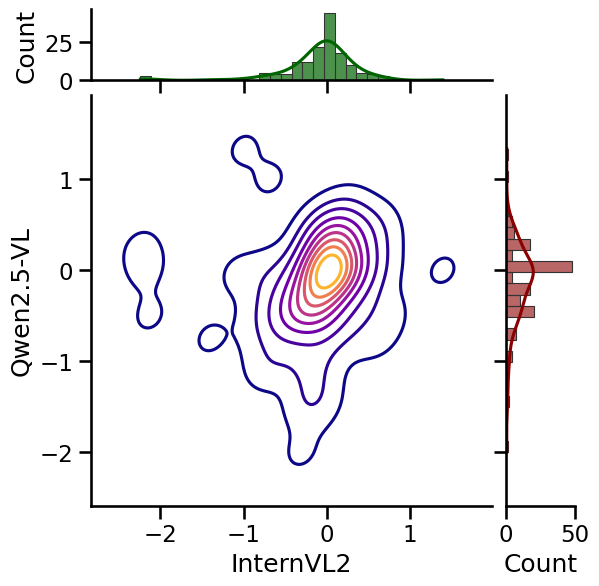

In [28]:
model_a = "internvl2"
model_b = "qwen2_5_vl"
keys_a = set(sample_means[model_a][ds].keys())
keys_b = set(sample_means[model_a][ds].keys())
common_ids = list(keys_a & keys_b)
distr_a = []
distr_b = []
for idx in common_ids:
    distr_a.append(sample_means[model_a][ds][idx])
    distr_b.append(sample_means[model_b][ds][idx])


sns.set_context("talk")
g = sns.JointGrid(x=distr_a, y=distr_b, marginal_ticks=True, height=6)
# Enable cbar to show scale
g.plot_joint(
    sns.kdeplot,
    color="navy",
    alpha=1.0,
    cmap="plasma",
    cbar=False,
)
g.set_axis_labels(xlabel="InternVL2", ylabel="Qwen2.5-VL")
sns.histplot(
    x=distr_a,
    ax=g.ax_marg_x,
    color="darkgreen",
    alpha=0.7,
    edgecolor=".2",
    kde=True,
)
sns.histplot(
    y=distr_b,
    ax=g.ax_marg_y,
    color="darkred",
    alpha=0.6,
    edgecolor=".2",
    kde=True,
)